#### TabNet Pytorch

TabNet is a deep-learning architecture (developed by Google Cloud) designed specifically for tabular datasets.

It uses sequential attention to choose which features to focus on at each decision step. That makes it more interpretable than a plain feed-forward ANN and sometimes better on structured data.

In [1]:
# Imports
import os, math, numpy as np, pandas as pd, torch
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.dummy import DummyRegressor
import warnings, logging
import json, joblib, matplotlib.pyplot as plt
from datetime import datetime
import torch
# Ignore Warnings
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"
logging.getLogger("pytorch_tabnet").setLevel(logging.ERROR)
logging.getLogger("sklearn").setLevel(logging.ERROR)

# Config
SEED = 42 #Same as before
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu" #RTX 4070

DATA_PATH = r"../data/entraineddropletfraction_VerticalFlow.csv"
feature_cols = ['D','Usg','UsL','rhol','rhog','st','MuL','Mug'] #8 features
target_col   = 'e'

# Training knobs
N_SPLITS   = 5
MAX_EPOCHS = 1800
PATIENCE   = 220
BATCH_SIZE = 256
VBS        = 64
USE_LOGIT_TARGET = True   # target E (0,1) benefits from logit-space training

# Small epsilon to avoid log(0) and log(1)
EPS = 1e-6

TABNET_PARAMS = dict(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    lambda_sparse=3e-4,
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(lr=3e-4, weight_decay=1e-4),
    scheduler_fn=torch.optim.lr_scheduler.ReduceLROnPlateau,
    scheduler_params=dict(mode="min", factor=0.85, patience=30, min_lr=1e-5),
    mask_type="sparsemax",
    verbose=0,
    device_name=DEVICE,
    seed=SEED,
)

#Load Data
df = pd.read_csv(DATA_PATH)
X = df[feature_cols].to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

#Helper func
def to_logit(yv: np.ndarray) -> np.ndarray:
    yv = np.clip(yv, EPS, 1 - EPS)
    return np.log(yv / (1 - yv))

def from_logit(z: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-z))

def make_strat_labels(y_cont, n_bins=7, min_per_bin=N_SPLITS):
    """Bin continuous y for StratifiedKFold."""
    for b in range(n_bins, 2, -1):
        qs = np.linspace(0, 1, b + 1)
        edges = np.unique(np.quantile(y_cont, qs))
        if len(edges) < 3:
            continue
        yb = np.digitize(y_cont, edges[1:-1], right=True)
        _, counts = np.unique(yb, return_counts=True)
        if np.all(counts >= min_per_bin):
            return yb
    med = np.median(y_cont)
    return (y_cont > med).astype(int)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sequential_attention_masks(model, X, feature_names, title="Sequential attention masks"):
    """
    Compute and plot the average attention mask per decision step.

    model          : fitted TabNetRegressor / TabNetClassifier
    X              : numpy array (n_samples, n_features) in the SAME space used for training
    feature_names  : list of feature names matching the columns of X
    """

    # Run TabNet's explain
    exp = model.explain(X)

    # Newer versions: explain returns (explain_matrix, masks)
    if isinstance(exp, tuple) and len(exp) == 2:
        explain_matrix, masks = exp
    else:
        # Fallback: only global explain returned
        explain_matrix = exp
        masks = None

    if masks is None:
        raise RuntimeError(
            "TabNet.explain() did not return per-step masks. "
            "Either your pytorch-tabnet version doesn't expose them, "
            "or explain() is behaving differently."
        )

    #Normalize masks into a list of 2D arrays: one per decision step

    if isinstance(masks, dict):
        # keys are step indices, values are (n_samples, n_features)
        step_keys = sorted(masks.keys())
        step_arrays = [np.asarray(masks[k]) for k in step_keys]
        ytick_labels = [f"Step {k}" for k in step_keys]
    elif isinstance(masks, (list, tuple)):
        step_arrays = [np.asarray(m) for m in masks]
        ytick_labels = [f"Step {i+1}" for i in range(len(step_arrays))]
    else:
        raise TypeError(f"Unexpected type for masks: {type(masks)}")

    # Average over samples to get a (n_steps, n_features) matrix
    step_importances = np.stack([m.mean(axis=0) for m in step_arrays])  # (n_steps, n_features)

    # --- Plot heatmap ---
    plt.figure(figsize=(8, 4.5), dpi=140)
    im = plt.imshow(step_importances, aspect="auto")
    plt.colorbar(im, label="Average mask value")

    plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha="right")
    plt.yticks(range(len(ytick_labels)), ytick_labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [3]:
# CV runner (StratifiedKFold, per-fold QuantileTransformer, robust loss)
def run_tabnet_cv(X_mat, y_vec, tabnet_params=TABNET_PARAMS):
    y_bins = make_strat_labels(y_vec, n_bins=7, min_per_bin=N_SPLITS)
    kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    fold_metrics = []
    best_model, best_rmse = None, math.inf

    print(f" TabNet CV ({DEVICE.upper()}) — Stratified on y")
    for fold, (tr, va) in enumerate(kf.split(X_mat, y_bins), 1):
        # Re-seed each fold for stability
        torch.manual_seed(SEED + fold)
        np.random.seed(SEED + fold)

        # Per-fold scaler (Quantile -> Normal) with safe quantiles
        n_q = min(100, len(tr))
        scaler = QuantileTransformer(output_distribution="normal",
                                     n_quantiles=n_q,
                                     random_state=SEED + fold)
        X_tr = scaler.fit_transform(X_mat[tr]).astype(np.float32)
        X_va = scaler.transform(X_mat[va]).astype(np.float32)
        y_tr = y_vec[tr].astype(np.float32)
        y_va = y_vec[va].astype(np.float32)

        # Baseline sanity
        base = DummyRegressor(strategy="mean").fit(X_tr, y_tr)
        base_pred = base.predict(X_va).astype(np.float32)
        base_rmse = root_mean_squared_error(y_va, base_pred)
        base_r2   = r2_score(y_va, base_pred)

        # Train space for target (logit)
        if USE_LOGIT_TARGET:
            y_tr_fit = to_logit(y_tr).reshape(-1, 1)
            y_va_fit = to_logit(y_va).reshape(-1, 1)
        else:
            y_tr_fit = y_tr.reshape(-1, 1)
            y_va_fit = y_va.reshape(-1, 1)

        # Robust loss helps occasional outliers
        loss_fn = torch.nn.SmoothL1Loss(beta=0.05)

        model = TabNetRegressor(cat_idxs=[], cat_dims=[], **tabnet_params)
        model.fit(
            X_train=X_tr, y_train=y_tr_fit,
            eval_set=[(X_va, y_va_fit)], eval_name=["valid"], eval_metric=["rmse"],
            max_epochs=MAX_EPOCHS, patience=PATIENCE,
            batch_size=BATCH_SIZE, virtual_batch_size=VBS,
            num_workers=0, pin_memory=True, drop_last=False,  # Windows/CUDA friendly
            loss_fn=loss_fn,
        )

        # Predict in logit space, then invert to [0,1]
        pred_fit = model.predict(X_va).ravel().astype(np.float32)
        y_pred = from_logit(pred_fit) if USE_LOGIT_TARGET else pred_fit

        rmse = root_mean_squared_error(y_va, y_pred)
        r2   = r2_score(y_va, y_pred)

        print(f"Fold {fold} | "
              f"TABNET R2={r2:.4f}, RMSE={rmse:.4f}")

        fold_metrics.append(dict(fold=fold, rmse=rmse, r2=r2,
                                 base_rmse=base_rmse, base_r2=base_r2))
        if rmse < best_rmse:
            best_rmse, best_model = rmse, model

        # Clear cude cache for stability on Windows
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    rmses = [m["rmse"] for m in fold_metrics]
    r2s   = [m["r2"] for m in fold_metrics]
    print(f"[TabNet] R² mean={np.mean(r2s):.4f} ± {np.std(r2s, ddof=1):.4f} | "
          f"RMSE mean={np.mean(rmses):.4f} ± {np.std(rmses, ddof=1):.4f}")
    return fold_metrics, best_model

#Run Cross-Validation
fold_metrics, best_model = run_tabnet_cv(X, y)

#Global feature importance
fi = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop TabNet features:\n", fi)


 TabNet CV (CUDA) — Stratified on y

Early stopping occurred at epoch 743 with best_epoch = 523 and best_valid_rmse = 0.8923299908638
Fold 1 | TABNET R2=0.7442, RMSE=0.1466

Early stopping occurred at epoch 1258 with best_epoch = 1038 and best_valid_rmse = 0.8982499837875366
Fold 2 | TABNET R2=0.7351, RMSE=0.1498

Early stopping occurred at epoch 1002 with best_epoch = 782 and best_valid_rmse = 0.8834599852561951
Fold 3 | TABNET R2=0.7229, RMSE=0.1506

Early stopping occurred at epoch 1016 with best_epoch = 796 and best_valid_rmse = 0.8200899958610535
Fold 4 | TABNET R2=0.7737, RMSE=0.1362

Early stopping occurred at epoch 1721 with best_epoch = 1501 and best_valid_rmse = 0.8363199830055237
Fold 5 | TABNET R2=0.7850, RMSE=0.1348
[TabNet] R² mean=0.7522 ± 0.0262 | RMSE mean=0.1436 ± 0.0076

Top TabNet features:
 rhol    0.187644
D       0.157078
UsL     0.154452
Usg     0.152530
rhog    0.123543
st      0.106274
Mug     0.078492
MuL     0.039987
dtype: float64


In [4]:
#imports  
import os, json, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import QuantileTransformer
from pytorch_tabnet.tab_model import TabNetRegressor
import torch

#Save CV results and best model
OUTDIR = "tabnet_report_outputs"
os.makedirs(OUTDIR, exist_ok=True)
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

#Save best fold model from CV (as-is)
best_path = os.path.join(OUTDIR, f"tabnet_best_fold_{stamp}")
best_model.save_model(best_path)  # creates {path}.zip
print(f"[saved] best fold TabNet to {best_path}.zip")

#Export per-fold metrics to CSV
df_folds = pd.DataFrame(fold_metrics)
df_folds.to_csv(os.path.join(OUTDIR, f"tabnet_cv_metrics_{stamp}.csv"), index=False)
print(f"[saved] CV metrics -> {OUTDIR}/tabnet_cv_metrics_{stamp}.csv")

#Export feature importances (from the best fold model)
fi = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fi.to_csv(os.path.join(OUTDIR, f"tabnet_feature_importance_bestfold_{stamp}.csv"), header=["importance"])
print(f"[saved] feature importances -> {OUTDIR}/tabnet_feature_importance_bestfold_{stamp}.csv")

# 7.4 Plot feature importances (bar chart) for slides
plt.figure(figsize=(7, 4.5), dpi=140)
fi.iloc[::-1].plot(kind="barh")  # reverse for descending top-to-bottom
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("TabNet Feature Importance (best fold)")
plt.tight_layout()
png_path = os.path.join(OUTDIR, f"tabnet_feature_importance_bestfold_{stamp}.png")
plt.savefig(png_path, bbox_inches="tight")
plt.close()
print(f"[saved] feature importance plot -> {png_path}")

# final model on all the data
def to_logit(yv):
    EPS = 1e-6
    yv = np.clip(yv, EPS, 1 - EPS)
    return np.log(yv / (1 - yv))

# build full-data scaler (same transform as in CV)
n_q = min(200, len(X))
full_scaler = QuantileTransformer(output_distribution="normal",
                                  n_quantiles=n_q, random_state=SEED)
X_full = full_scaler.fit_transform(X).astype(np.float32)

# copy params to avoid unintended side effects
final_params = dict(TABNET_PARAMS)
final_params["seed"] = SEED
final_params["device_name"] = "cuda" if torch.cuda.is_available() else "cpu"

final_model = TabNetRegressor(cat_idxs=[], cat_dims=[], **final_params)

# train target in logit space if chosen
if USE_LOGIT_TARGET:
    y_full_fit = to_logit(y).reshape(-1, 1).astype(np.float32)
else:
    y_full_fit = y.reshape(-1, 1).astype(np.float32)

# reuse preferred loss
loss_fn = torch.nn.MSELoss()

final_model.fit(
    X_train=X_full, y_train=y_full_fit,
    eval_set=[(X_full, y_full_fit)], eval_name=["full"], eval_metric=["rmse"],
    max_epochs=600, patience=100,  # shorter since it's just a polish on full data
    batch_size=256, virtual_batch_size=64,
    num_workers=0, pin_memory=True, drop_last=False,
    loss_fn=loss_fn,
)

final_base = os.path.join(OUTDIR, f"tabnet_full_data_{stamp}")
final_model.save_model(final_base)  # saves as .zip
joblib.dump(full_scaler, os.path.join(OUTDIR, f"tabnet_full_data_scaler_{stamp}.joblib"))
# persist flags needed at inference time
with open(os.path.join(OUTDIR, f"tabnet_full_data_meta_{stamp}.json"), "w") as f:
    json.dump({
        "feature_cols": feature_cols,
        "use_logit_target": USE_LOGIT_TARGET,
        "tabnet_params": {k: (str(v) if callable(v) else v) for k, v in TABNET_PARAMS.items()},
        "timestamp": stamp
    }, f, indent=2)

print(f"[saved] full-data TabNet -> {final_base}.zip")
print(f"[saved] full-data scaler -> {OUTDIR}/tabnet_full_data_scaler_{stamp}.joblib")
print(f"[saved] full-data meta   -> {OUTDIR}/tabnet_full_data_meta_{stamp}.json")


Successfully saved model at tabnet_report_outputs\tabnet_best_fold_20251203_120716.zip
[saved] best fold TabNet to tabnet_report_outputs\tabnet_best_fold_20251203_120716.zip
[saved] CV metrics -> tabnet_report_outputs/tabnet_cv_metrics_20251203_120716.csv
[saved] feature importances -> tabnet_report_outputs/tabnet_feature_importance_bestfold_20251203_120716.csv
[saved] feature importance plot -> tabnet_report_outputs\tabnet_feature_importance_bestfold_20251203_120716.png
Stop training because you reached max_epochs = 600 with best_epoch = 592 and best_full_rmse = 0.7114999890327454
Successfully saved model at tabnet_report_outputs\tabnet_full_data_20251203_120716.zip
[saved] full-data TabNet -> tabnet_report_outputs\tabnet_full_data_20251203_120716.zip
[saved] full-data scaler -> tabnet_report_outputs/tabnet_full_data_scaler_20251203_120716.joblib
[saved] full-data meta   -> tabnet_report_outputs/tabnet_full_data_meta_20251203_120716.json


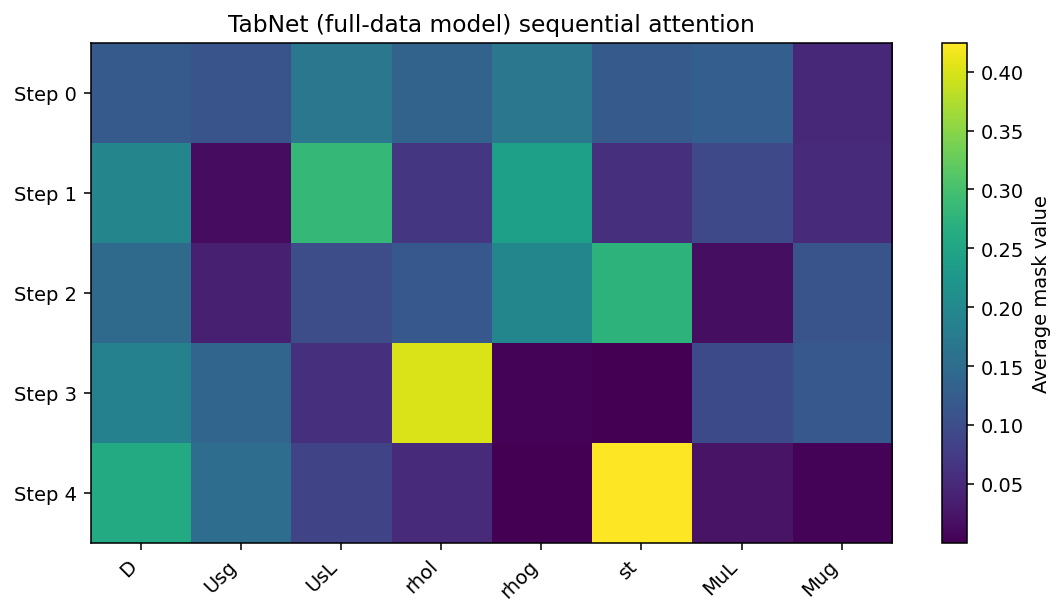

In [5]:
X_raw = df[feature_cols].to_numpy(dtype=np.float32)
X_full_scaled = full_scaler.transform(X_raw).astype(np.float32)

plot_sequential_attention_masks(
    final_model,
    X_full_scaled,
    feature_names=feature_cols,
    title="TabNet (full-data model) sequential attention"
)
